#### Implementation of GBM

In [1]:
# Importing libraries
import matplotlib.pyplot as plt
import numpy as np
import random
from matplotlib.gridspec import GridSpec

In [2]:
# Parameters 
mu = 0.2
sigma = 0.1

N = 10**5  # Number of trajectories
T = 1000   # Number of timesteps
dt = 0.01 # dt
time_vec = np.linspace(0,T*dt,1000)

In [3]:
# Generation of trajectories
x = np.zeros((N, T)) # Generating the arrows
x[:,0] = 1 # initial condition
time = np.arange(0,T*dt,dt)

for t in range(1,T):
    x[:,t] = x[:,t-1] * (1 + dt * mu + sigma * np.random.normal(0, np.sqrt(dt), size=N))

Plotting a single trajectory

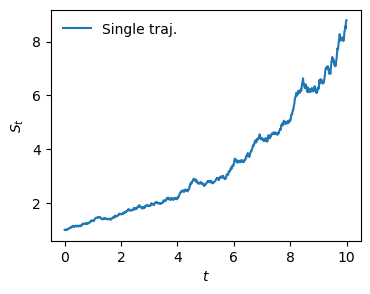

In [4]:
plt.figure(figsize=(4,3))

# Plotting a single trajectory
plt.plot(time, x[0, :], marker='none', alpha=1, label = r'Single traj.')

plt.xlabel(r'$t$')
plt.ylabel(r'$S_t$')
plt.legend(loc='best', frameon=False)

plt.show()

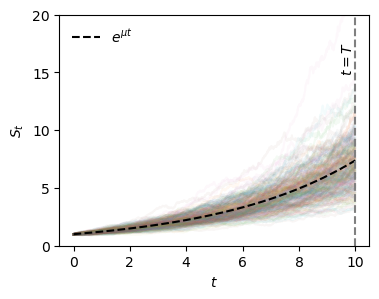

In [5]:
plt.figure(figsize=(4,3))

for i in range(250): # Take only 250
    plt.plot(time, x[i, :], marker='none', alpha=0.05)

# Average trajectory (theory)
st_average = np.exp(mu*time_vec)
plt.plot(time_vec, st_average, linestyle='--', color='black', label=r'$e^{\mu t}$')
plt.axvline(x=10, ymin=0, ymax= 20, linestyle = '--', color = 'grey')
plt.xlabel(r'$t$')
plt.ylabel(r'$S_t$')
plt.ylim([0,20])
plt.text(9.5, 15, r'$t = T$', rotation='vertical')
plt.yticks([0, 5, 10, 15, 20])
plt.legend(loc='best', frameon=False)

plt.show()

Histogram of the last value, at time $t = T$, along with the log normal distribution

In [6]:
# Def. the log normal distribution's probability density function
def log_normal(x,mu,sigma,t): # not the original, but the one for the GBM, provide mu, sigma and t
    prefactor = 1/(x * sigma * np.sqrt(2*np.pi*t) )
    num = (np.log(x) - (mu-0.5*sigma**2)*t)**2
    denom = 2 * sigma**2 * t
    f = prefactor * np. exp(-num/denom)
    return f

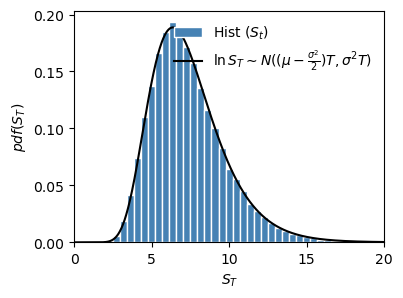

In [7]:
plt.figure(figsize=(4,3))

plt.hist(x[:, -1], bins=50, density=True, orientation='vertical', color='steelblue', edgecolor = 'white', label = r'Hist $(S_t)$')

# Prediction (log-normal)
t_teo = np.linspace(0.1,20,1000)
pdf_t = log_normal(t_teo,mu,sigma,10)
plt.plot(t_teo, pdf_t, color = 'black', label = r'$\ln S_T \sim N((\mu-\frac{\sigma^2}{2})T, \sigma^2 T)$')

# Plot configuration
plt.xlabel(r'$S_T$')
plt.ylabel(r'$pdf(S_T)$')
plt.xlim([0,20])
plt.legend(loc = 'upper right', frameon=False)
plt.show()

Sampling trajectories with different parameter sets (changing drift)

In [8]:
# Re-definition of parameters
mu_list = [0.1, 0.2, 0.3] # list of values for mu
sigma = 0.1

N = 10**5  # Number of trajectories
T = 1000   # Number of timesteps
dt = 0.01 # dt

In [9]:
# Generation of data.
x_T_matrix = [] # Keep data for each mu here (last step, t = T*dt)

for mu_i  in mu_list:
    # Generation of trajectories
    x = np.zeros((N, T)) # Generating the arrows
    x[:,0] = 1 # initial condition
    time = np.arange(0,T*dt,dt)

    for t in range(1,T):
        x[:,t] = x[:,t-1] * (1 + dt * mu_i + sigma * np.random.normal(0, np.sqrt(dt), size=N))

    # Append data of the last time step, at time t = T*dt
    x_T_matrix.append(x[:,-1])

print("Done")

Done


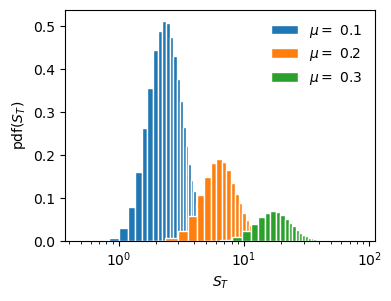

In [10]:
plt.figure(figsize=(4, 3))

for i in range(len(x_T_matrix)):
    # Plotting histogram(s)
    x_T = x_T_matrix[i]
    plt.hist(x_T, bins = 50, density=True, label = r'$\mu= $ '+str(mu_list[i]), edgecolor = 'white')

plt.xlabel(r'$S_T$')
plt.ylabel(r'pdf$(S_T)$')
# plt.yscale('log')
plt.xscale('log')
plt.legend(loc='best', frameon = False)
plt.show()

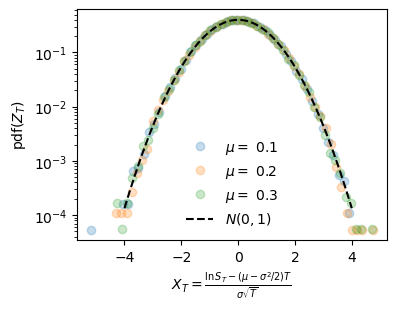

In [11]:
plt.figure(figsize=(4, 3))

for i in range(len(x_T_matrix)):
    # Plotting histogram
    x_T = x_T_matrix[i]
    z_T = (np.log(x_T) - (mu_list[i] -0.5*sigma**2)*T*dt )/(sigma*np.sqrt(T*dt)) 

    # Counting frequencies.
    counts, bin_edges = np.histogram(z_T, bins=50, density=True)
    # Compute center of bins
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    plt.plot(bin_centers, counts, 'o', label=r'$\mu=$ '+str(mu_list[i]), linestyle = 'none', alpha = 0.25)

# Plotting N(0,1)
z_gauss = np.linspace(-4,4, 500)
normal_gauss = (1/(np.sqrt(2*np.pi)))*np.exp(-0.5*(z_gauss**2))
plt.plot(z_gauss, normal_gauss, color = 'black', linestyle = '--', label = r'$N(0,1)$')

plt.xlabel(r'$X_T = \frac{\ln S_T - (\mu - \sigma^2/2)T}{\sigma \sqrt{T}}$')
plt.ylabel(r'pdf$(Z_T)$')
plt.yscale('log')
plt.legend(loc='best', frameon = False)
plt.show()

#### Testing GBM with real market data

While GBM provides a mathematically elegant and tractable model for asset prices, it is ultimately an idealization. In this section, we confront the model with real financial data.

We use historical price data (e.g., from equities or indices) and compute the log-returns:

\begin{equation}
    r_t = \log \left( \frac{S_t}{S_{t-\Delta t}} \right)
\end{equation}

The core assumptions of GBM that we aim to test are:

- Log-returns are normally distributed
- The mean and variance are constant (i.e., stationary increments)
- Returns are independent over time (no autocorrelation)

We visualize the data using histograms, QQ plots, and autocorrelation functions. We also estimate the drift and volatility empirically:

\begin{equation}
\bar{r_t} = \frac{1}{T} \sum_{t} r_t, \quad \sigma_{r_t}^2 = \frac{1}{T-1} \sum_t (r_t - \bar{r_t})^2
\end{equation}

This section helps to understand in which regimes GBM is a good approximation — and where it falls short, for instance due to fat tails, volatility clustering, or leverage effects. These observations motivate the need for more sophisticated models in real financial modeling.


In [12]:
# Uncom. to install Yahoo Finance
# !pip install yfinance

In [13]:
# Importing libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas_datareader import data as pdr
import yfinance as yf
import scipy.stats as stats

In [14]:
# Downloading directly using YahooFinance (yfinance)
asset = "GOOG"    # Google
#asset = "GC=F"    # Gold
#asset =  "^GSPC"   # S&P 500
#asset = "BTC-USD"  # Bitcoin
data = yf.download(f"{asset}", start="2020-01-01", end="2026-01-01")

# Showing the first rows
print(data.head())

C:\Users\adria\AppData\Local\Temp\ipykernel_22372\2216275409.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(f"{asset}", start="2020-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open    Volume
Ticker           GOOG       GOOG       GOOG       GOOG      GOOG
Date                                                            
2020-01-02  67.811760  67.849944  66.531272  66.531272  28132000
2020-01-03  67.479004  68.066186  66.729360  66.844216  23728000
2020-01-06  69.142838  69.256400  66.950335  66.950335  34646000
2020-01-07  69.099701  69.578270  68.952903  69.327831  30054000
2020-01-08  69.644226  70.004269  68.975711  69.037203  30560000


We will keep track of the closing value (at the end of the day)

In [15]:
data_v = data["Close"]
print(data_v)

Ticker            GOOG
Date                  
2020-01-02   67.811760
2020-01-03   67.479004
2020-01-06   69.142838
2020-01-07   69.099701
2020-01-08   69.644226
...                ...
2025-12-24  315.447784
2025-12-26  314.738251
2025-12-29  314.168701
2025-12-30  314.328552
2025-12-31  313.579071

[1508 rows x 1 columns]


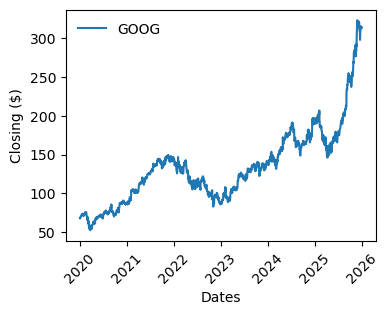

In [16]:
plt.figure(figsize=(4,3))

plt.plot(data_v, marker = 'none', label = f'{asset}')

plt.xlabel("Dates")
plt.ylabel("Closing ($)")
plt.xticks(rotation=45)
plt.legend(loc='best', frameon=False)
plt.show()

(log) daily returns

In [17]:
# Computing the returns
log_returns_daily = np.log(data_v / data_v.shift(1)).dropna() # Shift by one S_t -> S_{t-1}

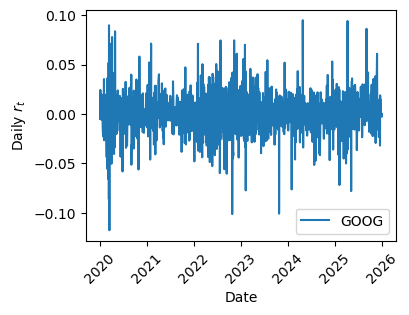

In [18]:
# Plotting the daily
plt.figure(figsize=(4,3))

plt.plot(log_returns_daily, marker='none', label = 'GOOG')

plt.xlabel("Date")
plt.ylabel(r"Daily $r_t$")
plt.xticks(rotation=45)
plt.legend(loc = 'best', frameon=True)
plt.show()

Take out statistical measures, such as the mean return $\bar{r}_t$ and the standard deviation $\sigma_{r_t} = \sqrt{\text{Var}(r_t)}$, compare distribuition to the Gaussian $\mathcal{N}(\bar{r}_t, \sigma_{r_t}^2)$.

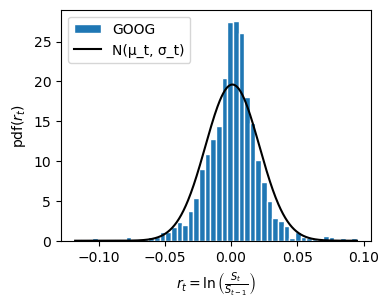

In [19]:
plt.figure(figsize=(4,3))

plt.hist(log_returns_daily, bins=50, density = True, label = f'{asset}', edgecolor = 'white')
x = np.linspace(log_returns_daily.min(), log_returns_daily.max(), 500)
plt.plot(x, stats.norm.pdf(x, log_returns_daily.mean(), log_returns_daily.std()), label="N(μ_t, σ_t)", color="black")
plt.legend(loc = 'best', fontsize = 10)
plt.xlabel(r'$r_t = \ln \left(\frac{S_{t}}{S_{t-1}}\right)$')
plt.ylabel(r'pdf$(r_t)$')
plt.show()

Standardized log returns;

In [20]:
log_returns_daily = np.array(log_returns_daily)
x_daily = (log_returns_daily-np.mean(log_returns_daily))/(np.std(log_returns_daily)) # This standarizes data

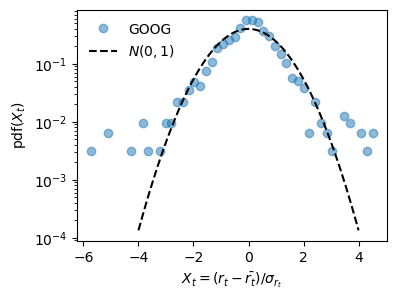

In [21]:
plt.figure(figsize=(4,3))

# Counting frequencies.
counts, bin_edges = np.histogram(x_daily, bins=50, density=True)
# Calcular centros de los bins
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
plt.plot(bin_centers, counts, 'o', label=f'{asset}', linestyle = 'none', alpha = 0.5)

# Plotting N(0,1)
z_gauss = np.linspace(-4,4, 500)
normal_gauss = (1/(np.sqrt(2*np.pi)))*np.exp(-0.5*(z_gauss**2))
plt.plot(z_gauss, normal_gauss, color = 'black', linestyle = '--', label = r'$N(0,1)$')

plt.xlabel(r'$X_t = (r_t-\bar{r_t})/\sigma_{r_t}$')
plt.ylabel(r'pdf$(X_t)$')
plt.yscale('log')
plt.legend(loc = 'best', frameon = False)
plt.show()